In [1]:
from glob import glob
import pickle as pk
import numpy as np
import dfibers.fixed_points as fx
from ising_finder import get_loss_factory
import torch as tr

def kron_prod(op_list):
    """Calculates the Kronecker product of a list of operators."""
    result = op_list[0]
    for op in op_list[1:]:
        result = tr.kron(result, op)
    return result


pauli = [
    tr.tensor([[1.0, 0.0], [0.0, 1.0]], dtype=tr.complex128),
    tr.tensor([[0.0, 1.0], [1.0, 0.0]], dtype=tr.complex128),
    tr.tensor([[0.0, -1j], [1j, 0.0]], dtype=tr.complex128),
    tr.tensor([[1.0, 0.0], [0.0, -1.0]], dtype=tr.complex128),
]

# number of qubits
n_qb = 6
# initial params
h=1.5; J = 1
initial_params = tr.tensor([[0, 0, h, J, 0, 0, 0, 0, h, -J, 0, 0]])

def get_Hamiltonian(c):
    """Creates the general ising Hamiltonian with boundary terms"""
    # c = [K,12], K is batch size
    K = c.shape[0]
    I_list = [pauli[0]] * n_qb
    H = tr.zeros((K, 2**n_qb, 2**n_qb), dtype=tr.complex128)

    # Interaction terms and Single Site terms
    for i in range(n_qb - 1):
        for p in range(1, 4):
            interaction_list = I_list[:]
            interaction_list[i] = pauli[p]
            interaction_list[i + 1] = pauli[p]

            single_term = I_list[:]
            single_term[i] = pauli[p]

            H += c[:, p - 1].view(K, 1, 1) * kron_prod(interaction_list) + c[
                :, 3 + p - 1
            ].view(K, 1, 1) * kron_prod(single_term)

    # Boundary Terms
    for p in range(1, 4):
        site_one = I_list[:]
        site_one[0] = pauli[p]

        site_N = I_list[:]
        site_N[n_qb - 1] = pauli[p]

        H += c[None, :, 6 + p - 1].view(K, 1, 1) * kron_prod(site_one) + c[
            None, :, 9 + p - 1
        ].view(K, 1, 1) * kron_prod(site_N)

    return H


def get_spectrum(c):
    # c is (K, 12) tensor, K is batch size
    H = get_Hamiltonian(c)
    try:
        spectrum = tr.linalg.eigvalsh(H)  # (K, 2**n_qb)
    except tr._C._LinAlgError:
        print("Erorr computing eigenvalues")
        with open("ErrorHamiltonian.txt", "w") as f:
            f.write(str(H))
            f.write("__________________________________\n")
        return np.inf
    return spectrum

init_spectrum = get_spectrum(initial_params)

def compute_diff_spectrum(R_i):
    lambda_i = get_spectrum(R_i)
    diff = tr.sum((lambda_i - init_spectrum) ** 2, dim=1)

    return diff


In [2]:
initial_starting_points = []
image_vectors:np.ndarray = np.empty((12,0))

image_vectors:np.ndarray

file_list = ["results/krammerswanier_plateau_params.pkl"]
file_list.extend(glob("results/krammerswanier_random_seed*.pkl"))


for file in file_list:
    with open(file, "rb") as f:
        (c_targ, V, A, R) = pk.load(f)

        # Add initial starting point
        initial_starting_points.append(c_targ)
        get_loss = get_loss_factory(c_targ)

        # Filter duplicate points and high-loss points
        duplicates = lambda U, v: (np.fabs(U - v) < 0.1).all(axis=0)
        R_init:np.ndarray = R.copy()
        R = fx.get_unique_points(R, duplicates)

        loss = get_loss(tr.tensor(R.T))
        keep = loss.numpy() < 1e-8

        # Trim arrays
        R = R[:, keep]

        # Store resulting trimmed results
        image_vectors = np.concatenate(
            (image_vectors, R.reshape(12,R.shape[1])), axis=1
        )

# Convert to numpy arrays
initial_starting_points = np.array(initial_starting_points)
image_vectors = np.array(image_vectors)


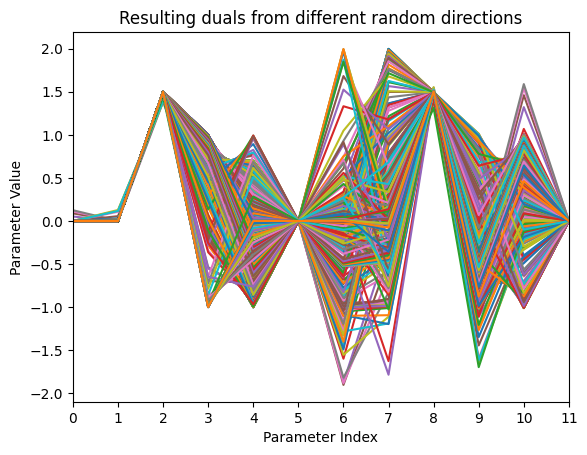

In [3]:
import matplotlib.pyplot as plt

plt.plot(image_vectors)
plt.xlim(0,11)
plt.xticks(range(12))
plt.xlabel("Parameter Index")
plt.ylabel("Parameter Value")
plt.title("Resulting duals from different random directions")

plt.show()

In [4]:
print(image_vectors[[2,5,8,11], 0])

[ 1.49999997e+00 -2.31128583e-11  1.49843346e+00 -9.80953839e-14]


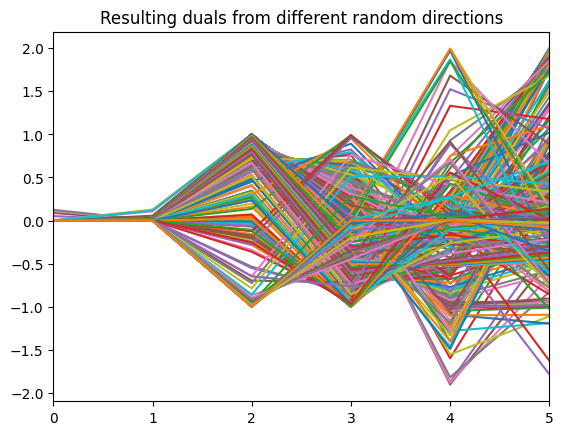

In [35]:
filtered_image_vectors = image_vectors[[0,1,3,4,6,7,9,10],:]
"""
Remove the constant values to determine what is truly changing in the data.
Removed: \sigma_z \sigma_z, \sigma_z^i, \sigma_z^0, \sigma_z^n
"""
plt.plot(filtered_image_vectors)
plt.xlim(0,5)
plt.xticks(range(6))
plt.title("Resulting duals from different random directions")

plt.show()